In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import yaml

In [2]:
with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)

In [3]:
final_demo = pl.read_csv(config["input_data"]["file1"])
final_demo.head()

client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
i64,f64,f64,f64,str,f64,f64,f64,f64
836976,6.0,73.0,60.5,"""U""",2.0,45105.3,6.0,9.0
2304905,7.0,94.0,58.0,"""U""",2.0,110860.3,6.0,9.0
1439522,5.0,64.0,32.0,"""U""",2.0,52467.79,6.0,9.0
1562045,16.0,198.0,49.0,"""M""",2.0,67454.65,3.0,6.0
5126305,12.0,145.0,33.0,"""F""",2.0,103671.75,0.0,3.0


In [4]:
experiment_data = pl.read_csv(config["input_data"]["file2"])
experiment_data.head()

client_id,Variation
i64,str
9988021,"""Test"""
8320017,"""Test"""
4033851,"""Control"""
1982004,"""Test"""
9294070,"""Control"""


In [5]:
webdata1 = pl.read_csv(config["input_data"]["file3"])
webdata1.head()

client_id,visitor_id,visit_id,process_step,date_time
i64,str,str,str,str
9988021,"""580560515_7732621733""","""781255054_21935453173_531117""","""step_3""","""2017-04-17 15:27:07"""
9988021,"""580560515_7732621733""","""781255054_21935453173_531117""","""step_2""","""2017-04-17 15:26:51"""
9988021,"""580560515_7732621733""","""781255054_21935453173_531117""","""step_3""","""2017-04-17 15:19:22"""
9988021,"""580560515_7732621733""","""781255054_21935453173_531117""","""step_2""","""2017-04-17 15:19:13"""
9988021,"""580560515_7732621733""","""781255054_21935453173_531117""","""step_3""","""2017-04-17 15:18:04"""


In [6]:
webdata2 = pl.read_csv(config["input_data"]["file2"])
webdata2.head()

client_id,Variation
i64,str
9988021,"""Test"""
8320017,"""Test"""
4033851,"""Control"""
1982004,"""Test"""
9294070,"""Control"""


In [7]:
webdata2["Variation"].value_counts()

Variation,count
str,u32
"""Test""",26968
"""Control""",23532
"""NA""",20109


In [8]:
webdata1["process_step"].value_counts().sort("count", descending=True)

process_step,count
str,u32
"""start""",108910
"""step_1""",73432
"""step_2""",61768
"""step_3""",53628
"""confirm""",45403


MERGED DATA

In [9]:
merged = pl.read_csv(config["output_data"]["file5"])
pl.DataFrame(merged).head()

,client_id,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
i64,i64,str,str,str,str,f64,f64,f64,str,f64,f64,f64,f64,str
0,9988021,"""580560515_7732621733""","""781255054_21935453173_531117""","""step_3""","""2017-04-17 15:27:07""",5.0,64.0,79.0,"""U""",2.0,189023.86,1.0,4.0,"""Test"""
1,9988021,"""580560515_7732621733""","""781255054_21935453173_531117""","""step_2""","""2017-04-17 15:26:51""",5.0,64.0,79.0,"""U""",2.0,189023.86,1.0,4.0,"""Test"""
2,9988021,"""580560515_7732621733""","""781255054_21935453173_531117""","""step_3""","""2017-04-17 15:19:22""",5.0,64.0,79.0,"""U""",2.0,189023.86,1.0,4.0,"""Test"""
3,9988021,"""580560515_7732621733""","""781255054_21935453173_531117""","""step_2""","""2017-04-17 15:19:13""",5.0,64.0,79.0,"""U""",2.0,189023.86,1.0,4.0,"""Test"""
4,9988021,"""580560515_7732621733""","""781255054_21935453173_531117""","""step_3""","""2017-04-17 15:18:04""",5.0,64.0,79.0,"""U""",2.0,189023.86,1.0,4.0,"""Test"""


Defining SEQ steps

In [10]:
df = pl.read_csv(config["output_data"]["file5"])

STEPS = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
STEP_ORDER = {step: i for step, i in zip(STEPS, range(len(STEPS)))}


In [11]:
client_visit_counts = (
    df
    .group_by(["Variation", "client_id"])
    .agg(
        pl.col("visit_id").n_unique().alias("n_visits")
    )
    .group_by(["Variation", "n_visits"])
    .agg(pl.len().alias("n_clients"))
    .sort(["Variation", "n_visits"])
)

print(client_visit_counts)

shape: (23, 3)
┌───────────┬──────────┬───────────┐
│ Variation ┆ n_visits ┆ n_clients │
│ ---       ┆ ---      ┆ ---       │
│ str       ┆ u32      ┆ u32       │
╞═══════════╪══════════╪═══════════╡
│ Control   ┆ 1        ┆ 14197     │
│ Control   ┆ 2        ┆ 2905      │
│ Control   ┆ 3        ┆ 614       │
│ Control   ┆ 4        ┆ 164       │
│ Control   ┆ 5        ┆ 56        │
│ …         ┆ …        ┆ …         │
│ Test      ┆ 6        ┆ 31        │
│ Test      ┆ 7        ┆ 8         │
│ Test      ┆ 8        ┆ 11        │
│ Test      ┆ 9        ┆ 2         │
│ Test      ┆ 10       ┆ 1         │
└───────────┴──────────┴───────────┘


Setting initial thought. STEP_ORDER so "errors" - processes that don't follow the step order - can be found and classified.

In [12]:
import polars as pl

STEP_ORDER = {"start": 0, "step_1": 1, "step_2": 2, "step_3": 3, "confirm": 4}
STEP_NAMES = {v: k for k, v in STEP_ORDER.items()}
REQUIRED_STEPS = set(STEP_ORDER.keys())
STEPS = ["start", "step_1", "step_2", "step_3", "confirm"]

df = (
    pl.read_csv(config["output_data"]["file5"])
    .with_columns([
        pl.col("date_time").str.to_datetime().alias("date_time"),
        pl.col("process_step").replace(STEP_ORDER).alias("step_rank"),
    ])
    .sort(["visit_id", "date_time"])
    .with_columns([
        pl.col("step_rank").shift(1).over("visit_id").alias("prev_step_rank"),
        pl.col("process_step").shift(1).over("visit_id").alias("prev_step_name"),
    ])
    .with_columns([
        (pl.col("step_rank") == pl.col("prev_step_rank")).alias("is_repetition"),
        (pl.col("step_rank") < pl.col("prev_step_rank")).alias("is_regression"),
    ])
    .with_columns(
        (pl.col("is_repetition") | pl.col("is_regression")).alias("is_error")
    )
)

def classify_visit(steps, step_ranks, had_error, n_regressions):
    steps = list(steps)
    step_ranks = list(step_ranks)

    # Invalid: sequence violation — a later step appears before an earlier one
    for i in range(len(STEPS) - 1):
        if STEPS[i] in steps and STEPS[i+1] in steps:
            if steps.index(STEPS[i+1]) < steps.index(STEPS[i]):
                return "invalid"

    # Incomplete: never reached confirm or missing steps
    if not REQUIRED_STEPS.issubset(set(steps)):
        return "incomplete"

    # Smooth: all steps, correct order, no errors
    if not had_error:
        return "smooth"

    # Lumpy: completed but with errors — distinguish type
    if n_regressions > 0:
        return "lumpy_regression"
    return "lumpy_repetition"

visit_agg = (
    df.group_by("visit_id").agg([
        pl.col("process_step").alias("steps_list"),
        pl.col("step_rank").alias("step_ranks_list"),
        pl.col("date_time").min().alias("visit_start"),
        pl.col("date_time").max().alias("visit_end"),
        pl.col("step_rank").max().alias("max_step_reached"),
        pl.col("is_error").any().alias("had_error"),
        pl.col("is_repetition").sum().alias("n_repetitions"),
        pl.col("is_regression").sum().alias("n_regressions"),
        pl.col("Variation").first().alias("variation"),
        pl.col("client_id").first().alias("client_id"),
        pl.col("visitor_id").first().alias("visitor_id"),
    ])
    .with_columns([
        (pl.col("visit_end") - pl.col("visit_start"))
            .dt.total_seconds()
            .alias("visit_duration_seconds"),
        pl.struct(["steps_list", "step_ranks_list", "had_error", "n_regressions"])
          .map_elements(
              lambda r: classify_visit(
                  r["steps_list"],
                  r["step_ranks_list"],
                  r["had_error"],
                  r["n_regressions"]
              ),
              return_dtype=pl.String
          )
          .alias("completion_type"),
    ])
    .with_columns(
        # dropped_at_step only meaningful for incomplete visits
        pl.when(pl.col("completion_type") == "incomplete")
            .then(pl.col("max_step_reached").cast(pl.String)
                    .replace({str(k): v for k, v in STEP_NAMES.items()}))
            .otherwise(pl.lit(None))
            .alias("dropped_at_step")
    )
)

print(
    visit_agg
    .group_by(["variation", "completion_type"])
    .agg(pl.len().alias("n_visits"))
    .sort(["variation", "completion_type"])
)

shape: (10, 3)
┌───────────┬──────────────────┬──────────┐
│ variation ┆ completion_type  ┆ n_visits │
│ ---       ┆ ---              ┆ ---      │
│ str       ┆ str              ┆ u32      │
╞═══════════╪══════════════════╪══════════╡
│ Control   ┆ incomplete       ┆ 12334    │
│ Control   ┆ invalid          ┆ 65       │
│ Control   ┆ lumpy_regression ┆ 2583     │
│ Control   ┆ lumpy_repetition ┆ 1250     │
│ Control   ┆ smooth           ┆ 7037     │
│ Test      ┆ incomplete       ┆ 14363    │
│ Test      ┆ invalid          ┆ 125      │
│ Test      ┆ lumpy_regression ┆ 3403     │
│ Test      ┆ lumpy_repetition ┆ 2507     │
│ Test      ┆ smooth           ┆ 8331     │
└───────────┴──────────────────┴──────────┘


For smooth:
- All 5 steps appear and in order
For lumpy:
- All 5 steps must appear
- Repetitions and regressions are allowed in between. Classified accordingly.
- They must be in correct order once the first occurance of the previous step is in correct order (start → 1 → 2 → 3 → confirm)
    So start-1-2-1-2-3-confirm IS OK (and will be regression) but start-2-1-3-confirm IS NOT (first occurrence of 2 comes before 1). These will be flagged "skip_after_regression" later, but considered as lumpy regression (unless % is too high).
For incomplete:
- started at "start", but never reached "confirm" in any visit
For invalid:
- did not start at "start" or had a loose step 

Finding skip_after_regression to understand its importance. If irrelevant, considering them as lumpy for the study.

In [13]:
def has_skip_after_regression(steps):
    steps = list(steps)
    for i in range(1, len(steps)):
        curr_rank = STEP_ORDER.get(steps[i], -1)
        prev_rank = STEP_ORDER.get(steps[i-1], -1)
        if curr_rank < prev_rank:  # regression detected
            for j in range(i, len(steps) - 1):
                r1 = STEP_ORDER.get(steps[j], -1)
                r2 = STEP_ORDER.get(steps[j+1], -1)
                if r2 > r1 + 1:  # skip detected after regression
                    return True
                if r2 < r1:  # another regression, stop this chain
                    break
    return False

# Run on your visit_agg before classification
skip_check = (
    df.sort(["visit_id", "date_time"])
    .group_by("visit_id")
    .agg([
        pl.col("process_step").alias("steps"),
        pl.col("Variation").first().alias("variation")
    ])
    .with_columns(
        pl.col("steps")
        .map_elements(lambda s: has_skip_after_regression(s.to_list()), return_dtype=pl.Boolean)
        .alias("skip_after_regression")
    )
)

total      = len(skip_check)
skip_count = skip_check["skip_after_regression"].sum()

print(f"Total visits:                      {total:,}")
print(f"Visits with skip after regression: {skip_count:,}")
print(f"Rate:                              {skip_count/total:.2%}")
print()
print(skip_check.filter(pl.col("skip_after_regression")).group_by("variation").agg(pl.len().alias("n_visits")))

print(f"\nNote: {skip_count} visits ({skip_count/total:.2%}) had a skip after regression.")
print(f"Test: 491 | Control: 26 — possible UI friction signal in Test group.")

Total visits:                      51,998
Visits with skip after regression: 517
Rate:                              0.99%

shape: (2, 2)
┌───────────┬──────────┐
│ variation ┆ n_visits │
│ ---       ┆ ---      │
│ str       ┆ u32      │
╞═══════════╪══════════╡
│ Control   ┆ 26       │
│ Test      ┆ 491      │
└───────────┴──────────┘

Note: 517 visits (0.99%) had a skip after regression.
Test: 491 | Control: 26 — possible UI friction signal in Test group.


Attempting to find error's per step. Trying different strategies.

In [ ]:
error_per_step = (
    df
    .filter(pl.col("is_error"))
    .group_by(["Variation", "process_step"])
    .agg([
        pl.len().alias("n_errors"),
        pl.col("is_repetition").sum().alias("n_repetitions"),
        pl.col("is_regression").sum().alias("n_regressions"),
    ])
    .join(
        df.group_by("Variation").agg(pl.len().alias("total_rows")),
        on="Variation"
    )
    .with_columns(
        (pl.col("n_errors") / pl.col("total_rows") * 100).round(2).alias("error_rate_%")
    )
    .sort(["Variation", "process_step"])
    .select(["Variation", "process_step", "n_errors", "n_repetitions", "n_regressions", "error_rate_%"])
)

print(error_per_step)

shape: (10, 6)
┌───────────┬──────────────┬──────────┬───────────────┬───────────────┬──────────────┐
│ Variation ┆ process_step ┆ n_errors ┆ n_repetitions ┆ n_regressions ┆ error_rate_% │
│ ---       ┆ ---          ┆ ---      ┆ ---           ┆ ---           ┆ ---          │
│ str       ┆ str          ┆ u32      ┆ u32           ┆ u32           ┆ f64          │
╞═══════════╪══════════════╪══════════╪═══════════════╪═══════════════╪══════════════╡
│ Control   ┆ confirm      ┆ 563      ┆ 563           ┆ 0             ┆ 0.56         │
│ Control   ┆ start        ┆ 8734     ┆ 6118          ┆ 2616          ┆ 8.68         │
│ Control   ┆ step_1       ┆ 2363     ┆ 845           ┆ 1518          ┆ 2.35         │
│ Control   ┆ step_2       ┆ 2658     ┆ 712           ┆ 1946          ┆ 2.64         │
│ Control   ┆ step_3       ┆ 690      ┆ 610           ┆ 80            ┆ 0.69         │
│ Test      ┆ confirm      ┆ 3058     ┆ 3058          ┆ 0             ┆ 2.19         │
│ Test      ┆ start        ┆

Finding Errors per step Transition. This goes further than "per step" announcing right away where the error ended up at. May be relevant or not.

In [15]:
# Errors per step transition — ranked buggiest to least buggy per group. Added ERROR RATE.
import polars as pl

pl.Config.set_tbl_rows(1000)
pl.Config.set_tbl_cols(100)

transition_errors = (
    df
    .filter(pl.col("is_error"))
    .with_columns(
        (pl.col("prev_step_name") + " -> " + pl.col("process_step")).alias("transition")
    )
    .group_by(["Variation", "transition"])
    .agg([
        pl.len().alias("n_errors"),
        pl.col("is_repetition").sum().alias("n_repetitions"),
        pl.col("is_regression").sum().alias("n_regressions"),
    ])
    .join(
        df.group_by("Variation").agg(pl.len().alias("total_rows")),
        on="Variation"
    )
    .with_columns(
        (pl.col("n_errors") / pl.col("total_rows")).alias("error_rate")
    )
    .sort(["Variation", "n_errors"], descending=[False, True])
)

# Buggiest transition per group
buggiest_per_group = (
    transition_errors
    .group_by("Variation")
    .agg(pl.all().sort_by("n_errors", descending=True).first())
    .sort("Variation")
)

print("=== Buggiest Transitions by Variation ===")
print(transition_errors)

print("\n=== Buggiest Transition Per Group ===")
print(buggiest_per_group.select(["Variation", "transition", "n_errors", "n_repetitions", "n_regressions", "error_rate"]))

=== Buggiest Transitions by Variation ===
shape: (29, 7)
┌───────────┬─────────────────┬──────────┬───────────────┬───────────────┬────────────┬────────────┐
│ Variation ┆ transition      ┆ n_errors ┆ n_repetitions ┆ n_regressions ┆ total_rows ┆ error_rate │
│ ---       ┆ ---             ┆ ---      ┆ ---           ┆ ---           ┆ ---        ┆ ---        │
│ str       ┆ str             ┆ u32      ┆ u32           ┆ u32           ┆ u32        ┆ f64        │
╞═══════════╪═════════════════╪══════════╪═══════════════╪═══════════════╪════════════╪════════════╡
│ Control   ┆ start -> start  ┆ 6118     ┆ 6118          ┆ 0             ┆ 100601     ┆ 0.060815   │
│ Control   ┆ step_3 ->       ┆ 1946     ┆ 0             ┆ 1946          ┆ 100601     ┆ 0.019344   │
│           ┆ step_2          ┆          ┆               ┆               ┆            ┆            │
│ Control   ┆ step_1 -> start ┆ 1152     ┆ 0             ┆ 1152          ┆ 100601     ┆ 0.011451   │
│ Control   ┆ step_1 ->       ┆ 84

Completion Rate vs Error Rate — Test vs Control.
- Trying to understand out of the completed, how many had errors.
- Meaning, out of COMPLETED (no incomplete, no invalid) how many were lumpy.

In [16]:
# Completion Rate vs Error Rate — Test vs Control
# Out of completed visits only, how many were smooth vs lumpy

completed_only = (
    visit_agg
    .filter(
        pl.col("completion_type").is_in(["smooth", "lumpy_regression", "lumpy_repetition"])
    )
)

error_within_completed = (
    completed_only
    .group_by(["variation", "completion_type"])
    .agg(pl.len().alias("n_visits"))
    .join(
        completed_only.group_by("variation").agg(pl.len().alias("total_completed")),
        on="variation"
    )
    .with_columns(
        (pl.col("n_visits") / pl.col("total_completed")).alias("rate")
    )
    .sort(["variation", "completion_type"])
)

print("=== Within Completed Visits: Smooth vs Lumpy by Variation ===")
print(error_within_completed)

# --- Conclusion ---
for variation in ["Test", "Control"]:
    group = error_within_completed.filter(pl.col("variation") == variation)
    smooth_rate = group.filter(pl.col("completion_type") == "smooth")["rate"][0]
    lumpy_rate = 1 - smooth_rate
    print(f"\n{variation}: {smooth_rate:.1%} of completions were smooth, {lumpy_rate:.1%} encountered errors along the way.")

=== Within Completed Visits: Smooth vs Lumpy by Variation ===
shape: (6, 5)
┌───────────┬──────────────────┬──────────┬─────────────────┬──────────┐
│ variation ┆ completion_type  ┆ n_visits ┆ total_completed ┆ rate     │
│ ---       ┆ ---              ┆ ---      ┆ ---             ┆ ---      │
│ str       ┆ str              ┆ u32      ┆ u32             ┆ f64      │
╞═══════════╪══════════════════╪══════════╪═════════════════╪══════════╡
│ Control   ┆ lumpy_regression ┆ 2583     ┆ 10870           ┆ 0.237626 │
│ Control   ┆ lumpy_repetition ┆ 1250     ┆ 10870           ┆ 0.114995 │
│ Control   ┆ smooth           ┆ 7037     ┆ 10870           ┆ 0.647378 │
│ Test      ┆ lumpy_regression ┆ 3403     ┆ 14241           ┆ 0.238958 │
│ Test      ┆ lumpy_repetition ┆ 2507     ┆ 14241           ┆ 0.176041 │
│ Test      ┆ smooth           ┆ 8331     ┆ 14241           ┆ 0.585001 │
└───────────┴──────────────────┴──────────┴─────────────────┴──────────┘

Test: 58.5% of completions were smooth, 41.5% e

- Completion rate = (smooth + lumpy visits) - anyone who reached confirm regardless of errors
- vs
- Incompletion Rate (incomplete + invalid) - anyone who did NOT finish process

In [17]:
# Completion Rate vs Error Rate — Test vs Control

completed_only = (
    visit_agg
    .filter(
        pl.col("completion_type").is_in(["smooth", "lumpy_regression", "lumpy_repetition"])
    )
)

error_within_completed = (
    completed_only
    .group_by(["variation", "completion_type"])
    .agg(pl.len().alias("n_visits"))
    .join(
        completed_only.group_by("variation").agg(pl.len().alias("total_completed")),
        on="variation"
    )
    .with_columns(
        (pl.col("n_visits") / pl.col("total_completed")).alias("rate")
    )
    .sort(["variation", "completion_type"])
)

completion_vs_not = (
    visit_agg
    .group_by(["variation", "completion_type"])
    .agg(pl.len().alias("n_visits"))
    .join(
        visit_agg.group_by("variation").agg(pl.len().alias("total_visits")),
        on="variation"
    )
    .with_columns(
        (pl.col("n_visits") / pl.col("total_visits")).alias("rate")
    )
    .sort(["variation", "completion_type"])
)

test_rate = completion_vs_not.filter(
    (pl.col("variation") == "Test") &
    pl.col("completion_type").is_in(["smooth", "lumpy_regression", "lumpy_repetition"])
)["rate"].sum()

control_rate = completion_vs_not.filter(
    (pl.col("variation") == "Control") &
    pl.col("completion_type").is_in(["smooth", "lumpy_regression", "lumpy_repetition"])
)["rate"].sum()

diff = test_rate - control_rate

print("=== Within Completed Visits: Smooth vs Lumpy by Variation ===")
print(error_within_completed)

print("\n=== Full Breakdown by Variation ===")
print(completion_vs_not)

print("\n=== Conclusion ===")
for variation, rate in [("Test", test_rate), ("Control", control_rate)]:
    group = completion_vs_not.filter(pl.col("variation") == variation)
    rates = {row["completion_type"]: row["rate"] for row in group.iter_rows(named=True)}
    incomplete = rates.get("incomplete", 0)
    invalid = rates.get("invalid", 0)
    print(f"{variation}: {rate:.1%} completed | {incomplete:.1%} incomplete | {invalid:.1%} invalid")

print(f"\nDifference (Test - Control): {diff:+.1%} — {'Test performs better' if diff > 0 else 'Control performs better'}")

=== Within Completed Visits: Smooth vs Lumpy by Variation ===
shape: (6, 5)
┌───────────┬──────────────────┬──────────┬─────────────────┬──────────┐
│ variation ┆ completion_type  ┆ n_visits ┆ total_completed ┆ rate     │
│ ---       ┆ ---              ┆ ---      ┆ ---             ┆ ---      │
│ str       ┆ str              ┆ u32      ┆ u32             ┆ f64      │
╞═══════════╪══════════════════╪══════════╪═════════════════╪══════════╡
│ Control   ┆ lumpy_regression ┆ 2583     ┆ 10870           ┆ 0.237626 │
│ Control   ┆ lumpy_repetition ┆ 1250     ┆ 10870           ┆ 0.114995 │
│ Control   ┆ smooth           ┆ 7037     ┆ 10870           ┆ 0.647378 │
│ Test      ┆ lumpy_regression ┆ 3403     ┆ 14241           ┆ 0.238958 │
│ Test      ┆ lumpy_repetition ┆ 2507     ┆ 14241           ┆ 0.176041 │
│ Test      ┆ smooth           ┆ 8331     ┆ 14241           ┆ 0.585001 │
└───────────┴──────────────────┴──────────┴─────────────────┴──────────┘

=== Full Breakdown by Variation ===
shape: (10,

Trying to spot differences by age/gender. EDIT: GENDER COLUMN NEEDS TO BE CLEAN

# Building demographics

In [18]:
client_demographics = (
    df
    .select(["client_id", "clnt_age"])
    .unique(subset=["client_id"])  # one row per client
    .rename({"clnt_age": "age"})
    .with_columns(
        pl.when(pl.col("age") <= 30).then(pl.lit("<30"))
          .when(pl.col("age") <= 45).then(pl.lit("30-50"))
          .when(pl.col("age") <= 60).then(pl.lit("50-70"))
          .otherwise(pl.lit("70+"))
          .alias("age_group")
    )
)

visit_agg_demo = visit_agg.join(client_demographics, on="client_id", how="left")
print(visit_agg_demo.select(["client_id", "age", "age_group"]).head(5))

shape: (5, 3)
┌───────────┬──────┬───────────┐
│ client_id ┆ age  ┆ age_group │
│ ---       ┆ ---  ┆ ---       │
│ i64       ┆ f64  ┆ str       │
╞═══════════╪══════╪═══════════╡
│ 3561384   ┆ 59.5 ┆ 50-70     │
│ 7338123   ┆ 23.5 ┆ <30       │
│ 105007    ┆ 35.0 ┆ 30-50     │
│ 5623007   ┆ 78.0 ┆ 70+       │
│ 4823947   ┆ 52.0 ┆ 50-70     │
└───────────┴──────┴───────────┘


Error rate by age_group

In [19]:
error_rate_demo = (
    visit_agg_demo
    .group_by(["variation", "age_group"])
    .agg([
        pl.len().alias("total_visits"),
        pl.col("had_error").cast(pl.Int32).sum().alias("visits_with_errors"),
    ])
    .with_columns(
        (pl.col("visits_with_errors") / pl.col("total_visits") * 100)
          .round(2).alias("error_rate_%")
    )
    .sort(["variation", "age_group"])
)
print(error_rate_demo)

shape: (8, 5)
┌───────────┬───────────┬──────────────┬────────────────────┬──────────────┐
│ variation ┆ age_group ┆ total_visits ┆ visits_with_errors ┆ error_rate_% │
│ ---       ┆ ---       ┆ ---          ┆ ---                ┆ ---          │
│ str       ┆ str       ┆ u32          ┆ i32                ┆ f64          │
╞═══════════╪═══════════╪══════════════╪════════════════════╪══════════════╡
│ Control   ┆ 30-50     ┆ 5803         ┆ 1820               ┆ 31.36        │
│ Control   ┆ 50-70     ┆ 7186         ┆ 2539               ┆ 35.33        │
│ Control   ┆ 70+       ┆ 6446         ┆ 2279               ┆ 35.36        │
│ Control   ┆ <30       ┆ 3834         ┆ 1309               ┆ 34.14        │
│ Test      ┆ 30-50     ┆ 7204         ┆ 2900               ┆ 40.26        │
│ Test      ┆ 50-70     ┆ 9014         ┆ 4313               ┆ 47.85        │
│ Test      ┆ 70+       ┆ 7808         ┆ 3817               ┆ 48.89        │
│ Test      ┆ <30       ┆ 4703         ┆ 1896               ┆ 

Error rate by gender & age

In [20]:
#Exploring Gender
df["gendr"].value_counts()



gendr,count
str,u32
"""F""",76579
"""X""",3
"""U""",82473
"""M""",80868
null,62


In [21]:
#Deleting null (string) and 'X'. Keeping "Unknown".
df = df.filter(
    (pl.col("gendr") != "null") & (pl.col("gendr") != "X")
)

In [22]:
# Gender distribution by Variation
gender_distribution = (
    df
    .unique(subset=["client_id"])  # one row per client to avoid counting same person multiple times
    .group_by(["Variation", "gendr"])
    .agg(pl.len().alias("n_clients"))
    .join(
        df.unique(subset=["client_id"]).group_by("Variation").agg(pl.len().alias("total_per_variation")),
        on="Variation"
    )
    .with_columns(
        (pl.col("n_clients") / pl.col("total_per_variation")).alias("rate")*100
    )
    .sort(["Variation", "gendr"])
)

print(gender_distribution)

shape: (6, 5)
┌───────────┬───────┬───────────┬─────────────────────┬───────────┐
│ Variation ┆ gendr ┆ n_clients ┆ total_per_variation ┆ rate      │
│ ---       ┆ ---   ┆ ---       ┆ ---                 ┆ ---       │
│ str       ┆ str   ┆ u32       ┆ u32                 ┆ f64       │
╞═══════════╪═══════╪═══════════╪═════════════════════╪═══════════╡
│ Control   ┆ F     ┆ 5678      ┆ 18012               ┆ 31.523429 │
│ Control   ┆ M     ┆ 6142      ┆ 18012               ┆ 34.099489 │
│ Control   ┆ U     ┆ 6192      ┆ 18012               ┆ 34.377082 │
│ Test      ┆ F     ┆ 7060      ┆ 22006               ┆ 32.082159 │
│ Test      ┆ M     ┆ 7317      ┆ 22006               ┆ 33.250023 │
│ Test      ┆ U     ┆ 7629      ┆ 22006               ┆ 34.667818 │
└───────────┴───────┴───────────┴─────────────────────┴───────────┘


In [23]:
error_rate_age_gender = (
    visit_agg_demo
    .join(
        df.unique(subset=["client_id"]).select(["client_id", "gendr"]),
        on="client_id"
    )
    .group_by(["variation", "age_group", "gendr"])
    .agg([
        pl.len().alias("total_visits"),
        pl.col("had_error").cast(pl.Int32).sum().alias("visits_with_errors"),
    ])
    .with_columns(
        (pl.col("visits_with_errors") / pl.col("total_visits") * 100)
          .round(2).alias("error_rate_%")
    )
    .sort(["variation", "age_group", "gendr"])
)
print(error_rate_age_gender)

shape: (24, 6)
┌───────────┬───────────┬───────┬──────────────┬────────────────────┬──────────────┐
│ variation ┆ age_group ┆ gendr ┆ total_visits ┆ visits_with_errors ┆ error_rate_% │
│ ---       ┆ ---       ┆ ---   ┆ ---          ┆ ---                ┆ ---          │
│ str       ┆ str       ┆ str   ┆ u32          ┆ i32                ┆ f64          │
╞═══════════╪═══════════╪═══════╪══════════════╪════════════════════╪══════════════╡
│ Control   ┆ 30-50     ┆ F     ┆ 1670         ┆ 497                ┆ 29.76        │
│ Control   ┆ 30-50     ┆ M     ┆ 2026         ┆ 594                ┆ 29.32        │
│ Control   ┆ 30-50     ┆ U     ┆ 2107         ┆ 729                ┆ 34.6         │
│ Control   ┆ 50-70     ┆ F     ┆ 2570         ┆ 872                ┆ 33.93        │
│ Control   ┆ 50-70     ┆ M     ┆ 2582         ┆ 867                ┆ 33.58        │
│ Control   ┆ 50-70     ┆ U     ┆ 2034         ┆ 800                ┆ 39.33        │
│ Control   ┆ 70+       ┆ F     ┆ 2456         ┆ 8

Smooth vs Lumpy by gender & age

In [24]:
smooth_lumpy_age_gender = (
    visit_agg_demo
    .join(
        df.unique(subset=["client_id"]).select(["client_id", "gendr"]),
        on="client_id"
    )
    .filter(
        pl.col("completion_type").is_in(["smooth", "lumpy_regression", "lumpy_repetition"])
    )
    .group_by(["variation", "age_group", "gendr", "completion_type"])
    .agg(pl.len().alias("n_visits"))
    .join(
        visit_agg_demo.group_by(["variation", "age_group"]).agg(pl.len().alias("total_visits")),
        on=["variation", "age_group"]
    )
    .with_columns(
        (pl.col("n_visits") / pl.col("total_visits") * 100)
          .round(2).alias("rate_%")
    )
    .sort(["variation", "age_group", "gendr", "completion_type"])
)
print(smooth_lumpy_age_gender)

shape: (72, 7)
┌───────────┬───────────┬───────┬──────────────────┬──────────┬──────────────┬────────┐
│ variation ┆ age_group ┆ gendr ┆ completion_type  ┆ n_visits ┆ total_visits ┆ rate_% │
│ ---       ┆ ---       ┆ ---   ┆ ---              ┆ ---      ┆ ---          ┆ ---    │
│ str       ┆ str       ┆ str   ┆ str              ┆ u32      ┆ u32          ┆ f64    │
╞═══════════╪═══════════╪═══════╪══════════════════╪══════════╪══════════════╪════════╡
│ Control   ┆ 30-50     ┆ F     ┆ lumpy_regression ┆ 177      ┆ 5803         ┆ 3.05   │
│ Control   ┆ 30-50     ┆ F     ┆ lumpy_repetition ┆ 87       ┆ 5803         ┆ 1.5    │
│ Control   ┆ 30-50     ┆ F     ┆ smooth           ┆ 587      ┆ 5803         ┆ 10.12  │
│ Control   ┆ 30-50     ┆ M     ┆ lumpy_regression ┆ 199      ┆ 5803         ┆ 3.43   │
│ Control   ┆ 30-50     ┆ M     ┆ lumpy_repetition ┆ 103      ┆ 5803         ┆ 1.77   │
│ Control   ┆ 30-50     ┆ M     ┆ smooth           ┆ 752      ┆ 5803         ┆ 12.96  │
│ Control   ┆ 30-

Starting Visuals

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm

Note on direction: I set this as two-tailed in H0/H1 — because for error rates you want to know if there's any difference, not just whether Test is worse. If the Test group has a significantly lower error rate, that's also a meaningful finding. The p-value approximation is one-tailed so multiply by 2 for a strict two-tailed test once you install scipy.

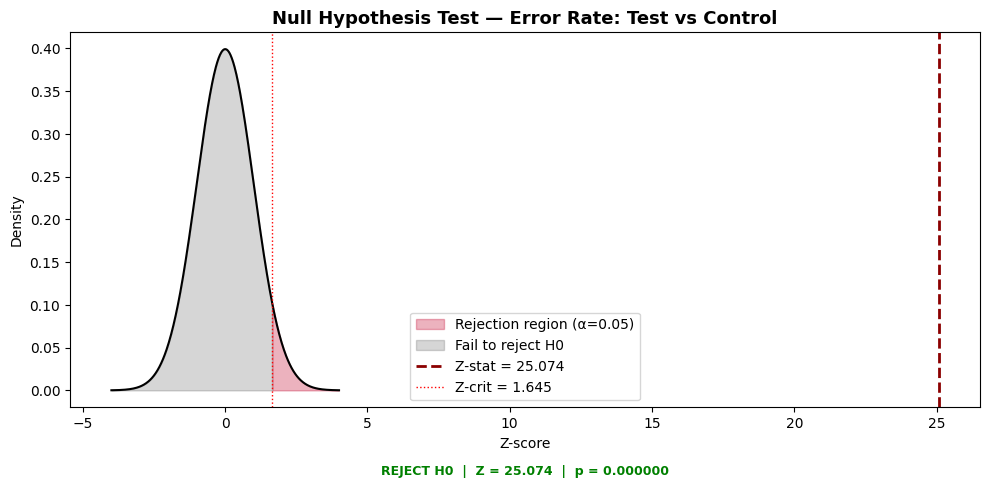

In [26]:
import numpy as np
import matplotlib.pyplot as plt

ALPHA = 0.05

# --- Numbers ---
test_visits    = visit_agg_demo.filter(pl.col("variation") == "Test")
control_visits = visit_agg_demo.filter(pl.col("variation") == "Control")

test_total    = len(test_visits)
control_total = len(control_visits)

test_errors    = test_visits["had_error"].cast(pl.Int32).sum()
control_errors = control_visits["had_error"].cast(pl.Int32).sum()

p_test    = test_errors / test_total
p_control = control_errors / control_total
p_pool    = (test_errors + control_errors) / (test_total + control_total)
se        = np.sqrt(p_pool * (1 - p_pool) * (1/test_total + 1/control_total))
z_stat    = (p_test - p_control) / se
p_value   = 0.5 * np.exp(-0.717 * z_stat - 0.416 * z_stat**2)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

x_range = np.linspace(-4, 4, 500)
y_range = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x_range**2)


COLOR_TEST    = "#C20029"
COLOR_CONTROL = "#333333"

ax.plot(x_range, y_range, color="black", linewidth=1.5)
ax.fill_between(x_range, y_range, where=(x_range >= 1.645), color=COLOR_TEST,       alpha=0.3, label="Rejection region (α=0.05)")
ax.fill_between(x_range, y_range, where=(x_range < 1.645),  color=COLOR_CONTROL, alpha=0.2, label="Fail to reject H0")
ax.axvline(z_stat, color="darkred", linewidth=2, linestyle="--", label=f"Z-stat = {z_stat:.3f}")
ax.axvline(1.645,  color="red",     linewidth=1, linestyle=":",  label="Z-crit = 1.645")

ax.set_title("Null Hypothesis Test — Error Rate: Test vs Control", fontsize=13, fontweight="bold")
ax.set_xlabel("Z-score")
ax.set_ylabel("Density")
ax.legend()

verdict = f"{'REJECT H0' if p_value < ALPHA else 'FAIL TO REJECT H0'}  |  Z = {z_stat:.3f}  |  p = {p_value:.6f}"
ax.text(0.5, -0.18, verdict, transform=ax.transAxes, ha="center",
        fontsize=9, fontweight="bold",
        color="green" if p_value < ALPHA else "red")

plt.tight_layout()
plt.show()

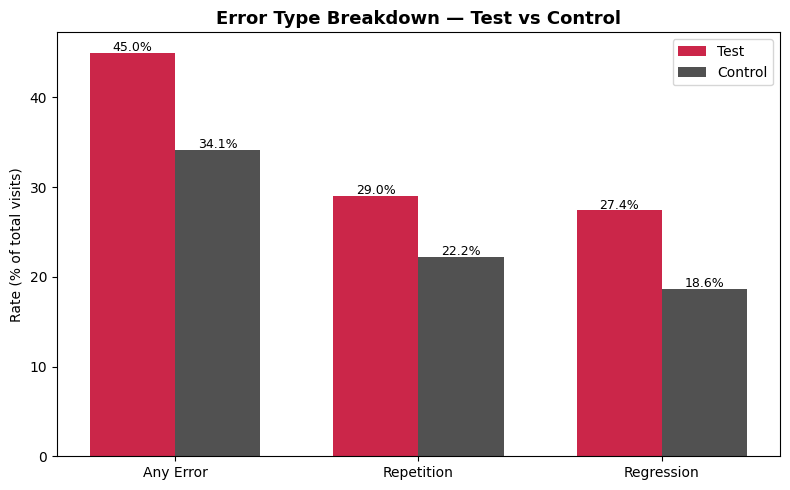

In [33]:
# --- Error type breakdown ---

error_breakdown = (
    visit_agg_demo
    .group_by("variation")
    .agg([
        pl.len().alias("total_visits"),
        pl.col("had_error").cast(pl.Int32).sum().alias("any_error"),
        pl.col("n_repetitions").gt(0).cast(pl.Int32).sum().alias("has_repetition"),
        pl.col("n_regressions").gt(0).cast(pl.Int32).sum().alias("has_regression"),
    ])
    .with_columns([
        (pl.col("any_error")      / pl.col("total_visits") * 100).round(2).alias("any_error_%"),
        (pl.col("has_repetition") / pl.col("total_visits") * 100).round(2).alias("repetition_%"),
        (pl.col("has_regression") / pl.col("total_visits") * 100).round(2).alias("regression_%"),
    ])
)

test_row    = error_breakdown.filter(pl.col("variation") == "Test").to_dicts()[0]
control_row = error_breakdown.filter(pl.col("variation") == "Control").to_dicts()[0]

# --- Plot ---
error_types  = ["Any Error", "Repetition", "Regression"]
test_vals    = [test_row["any_error_%"],    test_row["repetition_%"],    test_row["regression_%"]]
control_vals = [control_row["any_error_%"], control_row["repetition_%"], control_row["regression_%"]]

x = np.arange(len(error_types))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

COLOR_TEST    = "#C20029"
COLOR_CONTROL = "#333333"

bars_test    = ax.bar(x - w/2, test_vals,    w, label="Test",    color=COLOR_TEST,    alpha=0.85)
bars_control = ax.bar(x + w/2, control_vals, w, label="Control", color=COLOR_CONTROL, alpha=0.85)

for bar, val in zip(bars_test,    test_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f"{val:.1f}%", ha="center", fontsize=9)
for bar, val in zip(bars_control, control_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f"{val:.1f}%", ha="center", fontsize=9)

ax.set_title("Error Type Breakdown — Test vs Control", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(error_types)
ax.set_ylabel("Rate (% of total visits)")
ax.legend()

plt.tight_layout()
plt.show()

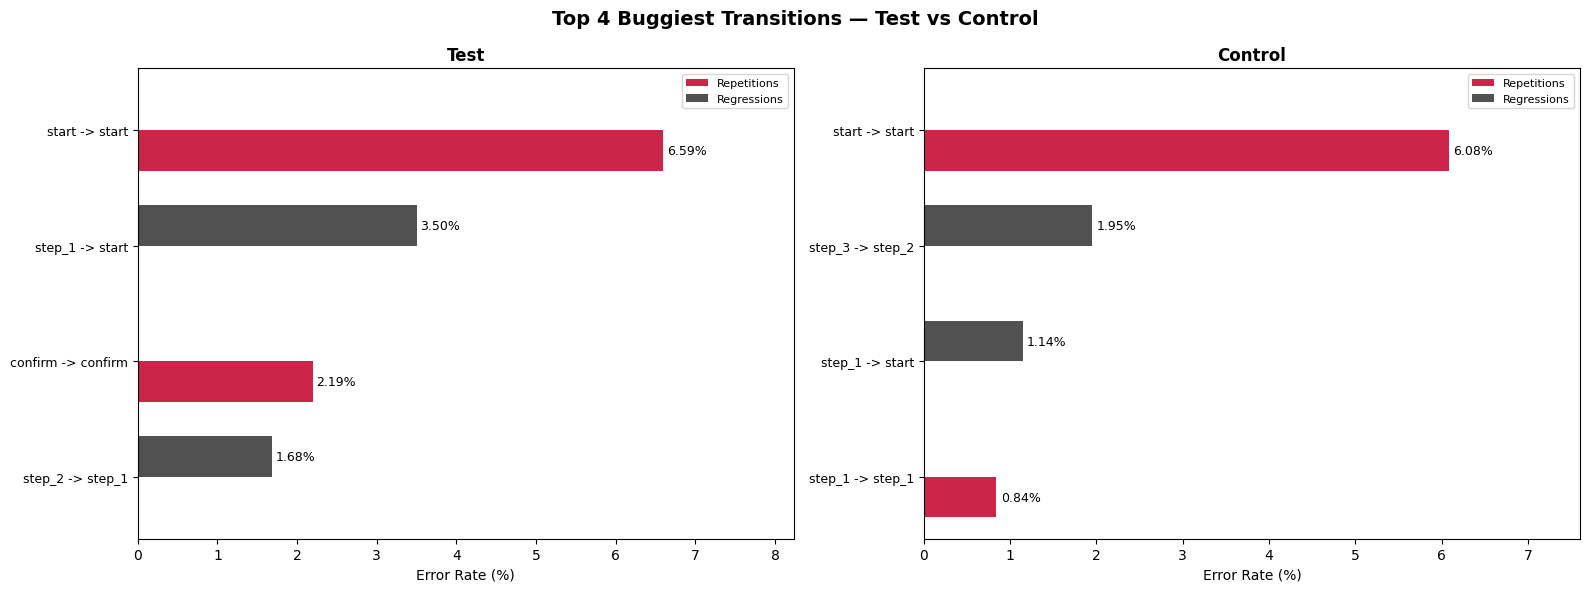

In [35]:
#Buggiest transition per group. Did the test solve the issue?

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig.suptitle("Top 4 Buggiest Transitions — Test vs Control", fontsize=14, fontweight="bold")

for ax, variation in zip(axes, ["Test", "Control"]):
    data = (
        transition_errors
        .filter(pl.col("Variation") == variation)
        .sort("error_rate", descending=True)
        .head(4)
    )
    transitions  = data["transition"].to_list()
    rep_rates    = (data["n_repetitions"] / data["total_rows"] * 100).to_list()
    reg_rates    = (data["n_regressions"] / data["total_rows"] * 100).to_list()



    COLOR_TEST    = "#C20029"
    COLOR_CONTROL = "#333333"
    x = np.arange(len(transitions))
    w = 0.35

    ax.barh(x + w/2, rep_rates, w, label="Repetitions", color=COLOR_TEST, alpha=0.85)
    ax.barh(x - w/2, reg_rates, w, label="Regressions", color=COLOR_CONTROL, alpha=0.85)

    for i, (rep, reg) in enumerate(zip(rep_rates, reg_rates)):
        if rep > 0:
            ax.text(rep + 0.05, i + w/2, f"{rep:.2f}%", va="center", fontsize=9)
        if reg > 0:
            ax.text(reg + 0.05, i - w/2, f"{reg:.2f}%", va="center", fontsize=9)

    ax.set_title(variation, fontsize=12, fontweight="bold")
    ax.set_yticks(x)
    ax.set_yticklabels(transitions, fontsize=9)
    ax.set_xlabel("Error Rate (%)")
    ax.set_xlim(0, max(rep_rates + reg_rates) * 1.25)  # extra space for labels
    ax.invert_yaxis()
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

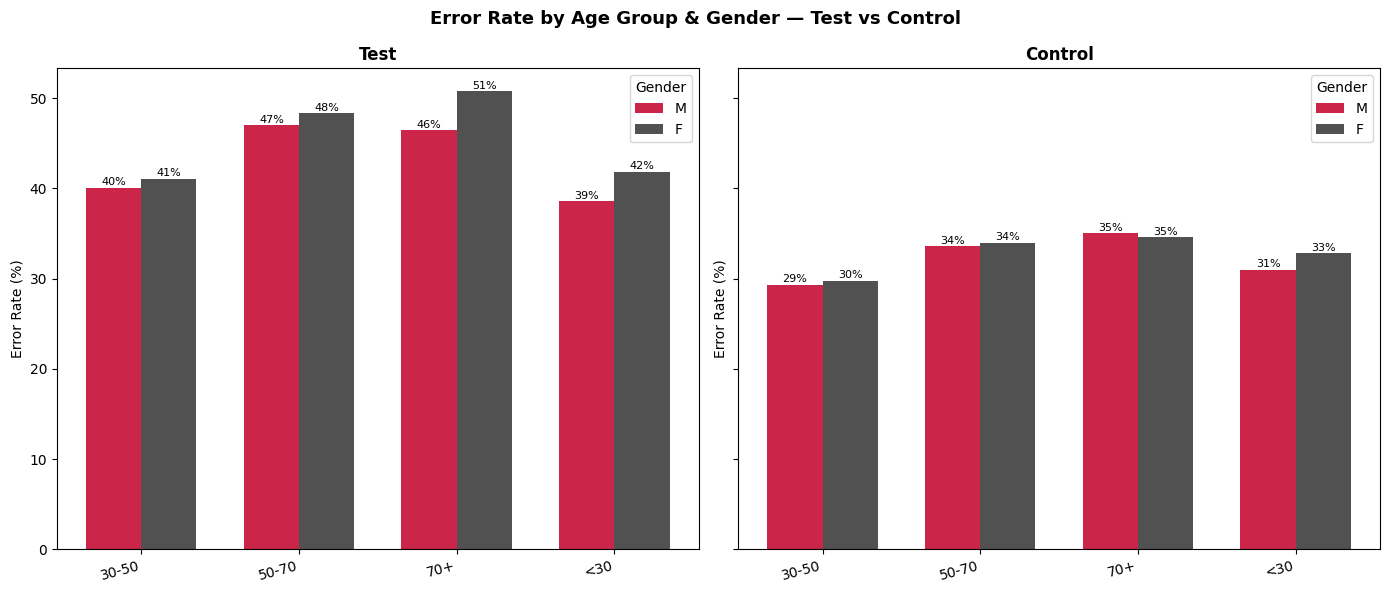

In [36]:
# --- Error rate by age group and gender ---
error_age_gender = (
    visit_agg_demo
    .join(
        df.unique(subset=["client_id"]).select(["client_id", "gendr"]),
        on="client_id"
    )
    .filter(pl.col("gendr").is_in(["M", "F"]))  # exclude U and X for clarity
    .group_by(["variation", "age_group", "gendr"])
    .agg([
        pl.len().alias("total_visits"),
        pl.col("had_error").cast(pl.Int32).sum().alias("visits_with_errors"),
    ])
    .with_columns(
        (pl.col("visits_with_errors") / pl.col("total_visits") * 100).round(2).alias("error_rate_%")
    )
    .sort(["variation", "age_group", "gendr"])
)

age_groups = sorted(error_age_gender["age_group"].unique().to_list())
genders    = ["M", "F"]
variations = ["Test", "Control"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle("Error Rate by Age Group & Gender — Test vs Control", fontsize=13, fontweight="bold")


COLOR_TEST    = "#C20029"
COLOR_CONTROL = "#333333"
x = np.arange(len(age_groups))
w = 0.35

for ax, variation in zip(axes, variations):
    for i, gender in enumerate(genders):
        vals = []
        for age in age_groups:
            row = error_age_gender.filter(
                (pl.col("variation") == variation) &
                (pl.col("age_group") == age) &
                (pl.col("gendr") == gender)
            )
            vals.append(row["error_rate_%"][0] if len(row) > 0 else 0)

        offset = -w/2 if gender == "M" else w/2
        bars = ax.bar(x + offset, vals, w, label=gender, color=COLOR_TEST if gender == "M" else COLOR_CONTROL, alpha=0.85)

        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{val:.0f}%", ha="center", fontsize=8)

    ax.set_title(variation, fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(age_groups, rotation=15, ha="right")
    ax.set_ylabel("Error Rate (%)")
    ax.legend(title="Gender")

plt.tight_layout()
plt.show()

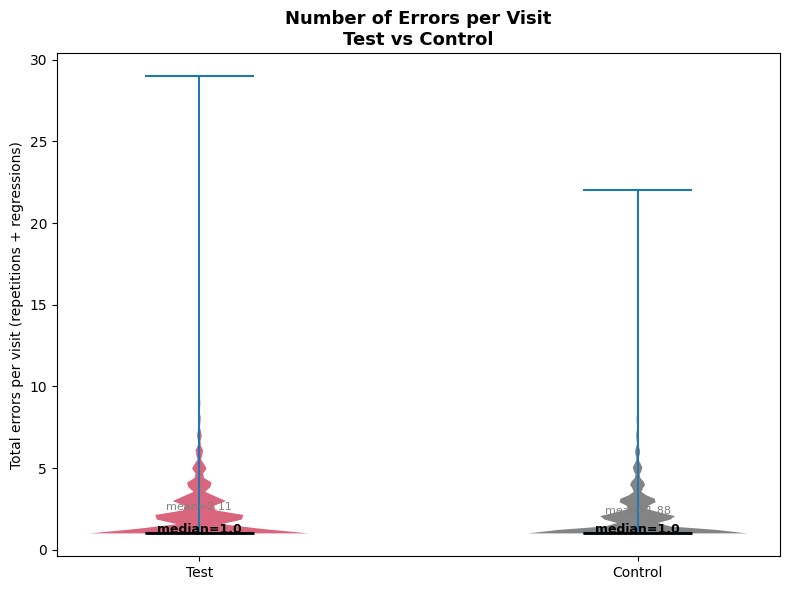

In [37]:
# --- Number of errors per visit — violin only ---
test_errors_dist = (
    visit_agg_demo.filter(pl.col("variation") == "Test")["n_repetitions"] +
    visit_agg_demo.filter(pl.col("variation") == "Test")["n_regressions"]
)
control_errors_dist = (
    visit_agg_demo.filter(pl.col("variation") == "Control")["n_repetitions"] +
    visit_agg_demo.filter(pl.col("variation") == "Control")["n_regressions"]
)

test_errors_dist    = test_errors_dist.filter(test_errors_dist > 0).to_list()
control_errors_dist = control_errors_dist.filter(control_errors_dist > 0).to_list()

fig, ax = plt.subplots(figsize=(8, 6))

violin = ax.violinplot([test_errors_dist, control_errors_dist],
                        positions=[1, 2], showmedians=True, showextrema=True)


violin["bodies"][0].set_facecolor(COLOR_TEST)
violin["bodies"][1].set_facecolor(COLOR_CONTROL)
for body in violin["bodies"]:
    body.set_alpha(0.6)

violin["cmedians"].set_color("black")
violin["cmedians"].set_linewidth(2)

ax.set_title("Number of Errors per Visit\nTest vs Control", fontsize=13, fontweight="bold")
ax.set_xticks([1, 2])
ax.set_xticklabels(["Test", "Control"])
ax.set_ylabel("Total errors per visit (repetitions + regressions)")

for pos, data in zip([1, 2], [test_errors_dist, control_errors_dist]):
    ax.text(pos, np.median(data) + 0.05, f"median={np.median(data):.1f}",
            ha="center", fontsize=9, fontweight="bold")
    ax.text(pos, np.mean(data)   + 0.3,  f"mean={np.mean(data):.2f}",
            ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

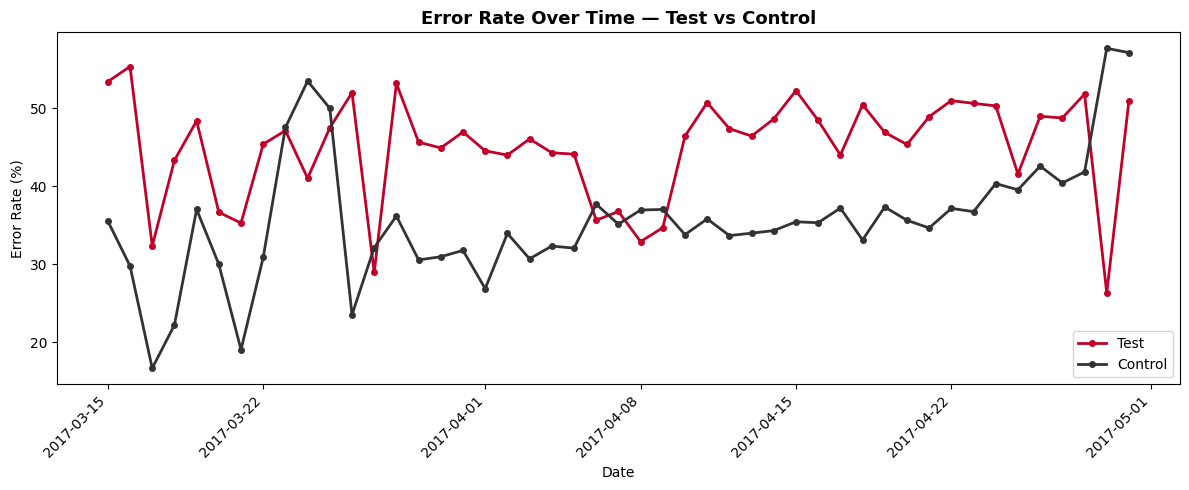

In [38]:
# --- Error rate over time ---
error_over_time = (
    visit_agg_demo
    .with_columns(
        pl.col("visit_start").cast(pl.Date).alias("visit_date")
    )
    .group_by(["variation", "visit_date"])
    .agg([
        pl.len().alias("total_visits"),
        pl.col("had_error").cast(pl.Int32).sum().alias("visits_with_errors"),
    ])
    .with_columns(
        (pl.col("visits_with_errors") / pl.col("total_visits") * 100).round(2).alias("error_rate_%")
    )
    .sort(["variation", "visit_date"])
)

test_time    = error_over_time.filter(pl.col("variation") == "Test")
control_time = error_over_time.filter(pl.col("variation") == "Control")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(test_time["visit_date"].to_list(),    test_time["error_rate_%"].to_list(),
        color=COLOR_TEST,  linewidth=2, label="Test",    marker="o", markersize=4)
ax.plot(control_time["visit_date"].to_list(), control_time["error_rate_%"].to_list(),
        color=COLOR_CONTROL, linewidth=2, label="Control", marker="o", markersize=4)

ax.set_title("Error Rate Over Time — Test vs Control", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Error Rate (%)")
ax.legend()
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

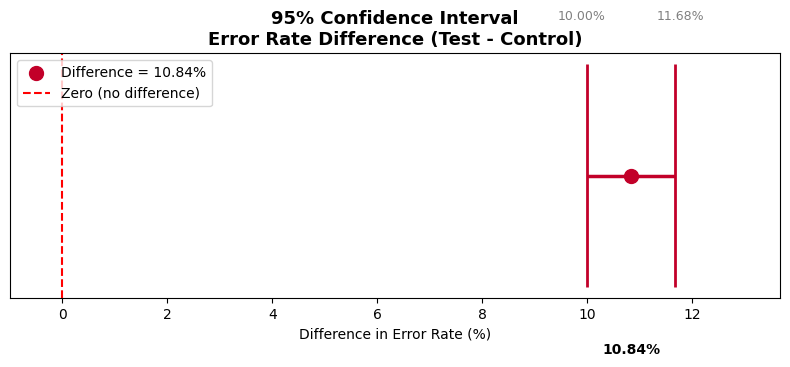

In [39]:
# --- Confidence Interval Plot ---
diff    = p_test - p_control
se_diff = np.sqrt((p_test*(1-p_test)/test_total) + (p_control*(1-p_control)/control_total))
ci_low  = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff

fig, ax = plt.subplots(figsize=(8, 4))

# point estimate
ax.scatter(diff * 100, 1, color=COLOR_TEST, zorder=5, s=100, label=f"Difference = {diff*100:.2f}%")

# confidence interval line
ax.hlines(1, ci_low * 100, ci_high * 100, color=COLOR_TEST, linewidth=2.5)
ax.vlines(ci_low  * 100, 0.95, 1.05, color=COLOR_TEST, linewidth=2)
ax.vlines(ci_high * 100, 0.95, 1.05, color=COLOR_TEST, linewidth=2)

# zero line
ax.axvline(0, color="red", linewidth=1.5, linestyle="--", label="Zero (no difference)")

# labels
ax.text(ci_low  * 100 - 0.1, 1.07, f"{ci_low*100:.2f}%",  ha="center", fontsize=9, color="gray")
ax.text(ci_high * 100 + 0.1, 1.07, f"{ci_high*100:.2f}%", ha="center", fontsize=9, color="gray")
ax.text(diff    * 100,        0.92, f"{diff*100:.2f}%",    ha="center", fontsize=10, fontweight="bold")

ax.set_title("95% Confidence Interval\nError Rate Difference (Test - Control)", fontsize=13, fontweight="bold")
ax.set_xlabel("Difference in Error Rate (%)")
ax.set_xlim(min(ci_low * 100 - 2, -1), ci_high * 100 + 2)
ax.set_yticks([])
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()